# **Deteksi Aksara Jawa | K-Nearest Neighbous**

Model terjemah dataset numerik aksara jawa menggunakan algoritma K-Nearest Neighbous.

**Dikerjakan oleh**:
- Akhyar Bima 
- Silmy Muthi'ah Aulya

**SMK Negeri 2 Singosari**

## 1. Data Preparation

### 1.1 Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import messagebox


### 1.2 Read Dataset 

In [3]:
# Baca file excel 
xls = pd.ExcelFile('Data - Non Label.xlsx')
xls.sheet_names

['Training', 'Testing']

In [4]:
# Simpan data train dan test
df_train = pd.read_excel('Data - Non Label.xlsx', sheet_name='Training')
df_test = pd.read_excel('Data - Non Label.xlsx', sheet_name='Testing')

In [5]:
# Impor file csv
try:
    df_train.to_csv('data_train.csv', index=False)
    df_test.to_csv('data_test.csv', index=False)
    print('Data berhasil terbaca.')

except ValueError:
    print('Dataset gagal terbaca.')

Data berhasil terbaca.


In [6]:
# data train
print('5 baris teratas data train:\n')
df_train.head()

5 baris teratas data train:



,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
0,1,HA,274,72,222,170,160,180,105,138,110,214,104,131,105,242,114,123
1,1,HA,114,3,77,87,56,51,104,94,56,45,164,61,36,92,110,31
2,1,HA,279,182,348,286,322,191,170,181,316,157,203,179,300,302,185,176
3,1,HA,92,53,202,117,67,76,153,83,66,75,146,78,56,142,90,60
4,1,HA,280,35,255,191,155,153,218,163,131,237,207,160,103,264,117,133


In [7]:
# data test
print('5 baris teratas data test:\n')
df_test.head()

5 baris teratas data test:



,No. Urut,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
0,1,192,200,68,280,148,188,343,253,166,187,156,313,148,76,16,146
1,2,142,87,0,234,150,297,0,225,96,278,0,240,96,88,168,114
2,3,149,160,67,224,135,155,159,157,139,136,159,150,136,158,248,179
3,4,177,100,167,170,91,104,92,95,101,210,97,108,90,240,200,98
4,5,273,62,341,344,196,39,143,252,224,0,120,234,159,95,118,47


In [8]:

print('10 baris acak:')
df_train.sample(10)

10 baris acak:


,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
272,12,DHA,23,145,109,275,105,94,0,182,103,111,31,187,109,189,191,37
69,3,CA,164,119,223,183,109,119,99,108,118,251,192,103,85,269,181,105
150,6,LA,118,106,31,107,87,97,56,65,80,87,73,61,53,23,73,11
203,8,SA,144,114,54,189,81,104,93,96,91,199,108,118,9,218,126,87
171,7,TA,232,61,301,304,202,101,244,165,262,12,274,141,158,209,196,130
385,18,BA,93,51,141,64,49,48,79,49,52,82,78,60,62,85,59,46
147,6,LA,323,281,83,215,152,153,299,156,152,149,302,169,139,137,407,131
345,16,MA,301,34,153,266,370,62,158,151,263,15,171,157,170,195,83,58
47,3,CA,182,109,237,205,120,126,120,116,121,132,110,94,123,276,196,79
26,2,NaN,105,87,71,110,79,88,103,87,70,121,186,88,59,65,0,87


In [9]:
# Dimensi data
print('Dimensi data:\n')
print('Data train:')
print('Jumlah baris:', df_train.shape[0])
print('Jumlah kolom:', df_train.shape[1])

print('\nData test:')
print('Jumlah baris:', df_test.shape[0])
print('Jumlah kolom:', df_test.shape[1])

Dimensi data:

Data train:
Jumlah baris: 450
Jumlah kolom: 18

Data test:
Jumlah baris: 150
Jumlah kolom: 17


In [10]:
# Ringkasan informasi 
print('Ringkasan Informasi:\n')
df_train.info()

Ringkasan Informasi:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   No      450 non-null    int64 
 1   HURUF   426 non-null    object
 2   Z1      450 non-null    int64 
 3   Z2      450 non-null    int64 
 4   Z3      450 non-null    int64 
 5   Z4      450 non-null    int64 
 6   Z5      450 non-null    int64 
 7   Z6      450 non-null    int64 
 8   Z7      450 non-null    int64 
 9   Z8      450 non-null    int64 
 10  Z9      450 non-null    int64 
 11  Z10     450 non-null    int64 
 12  Z11     450 non-null    int64 
 13  Z12     450 non-null    int64 
 14  Z13     450 non-null    int64 
 15  Z14     450 non-null    int64 
 16  Z15     450 non-null    int64 
 17  Z16     450 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 63.4+ KB


In [11]:
# Ringkasan statistik
print('Ringkasan statistik:')
df_train.describe()

Ringkasan statistik:


,No,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,10.168889,167.551111,117.206667,160.411111,202.644444,123.248889,127.000000,107.164444,150.871111,119.808889,138.537778,129.624444,146.600000,94.586667,152.553333,120.833333,99.691111
std,5.864689,89.893742,93.541146,102.802630,86.359392,73.046681,77.899541,82.892689,67.510760,73.077156,88.554060,98.459962,64.726149,62.378633,91.440674,86.510327,56.594798
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,100.000000,49.000000,81.250000,140.000000,71.000000,73.000000,47.000000,104.000000,73.000000,79.000000,61.000000,95.250000,54.000000,88.250000,61.250000,59.250000
50%,9.000000,151.500000,91.000000,149.500000,189.000000,110.000000,116.500000,101.500000,142.000000,105.500000,122.500000,113.000000,139.500000,81.500000,137.500000,110.000000,93.000000
75%,15.000000,232.000000,165.750000,225.750000,252.000000,163.000000,166.500000,155.750000,194.750000,159.750000,181.000000,184.000000,194.000000,123.000000,206.000000,177.000000,131.000000
max,20.000000,528.000000,504.000000,457.000000,599.000000,427.000000,537.000000,403.000000,366.000000,423.000000,463.000000,523.000000,370.000000,342.000000,474.000000,416.000000,310.000000


In [12]:
# Penyebaran data label
print('Penyebaran data label:')
df_train['No'].value_counts()

Penyebaran data label:


No
6     46
2     24
1     23
3     23
4     23
5     23
7     23
8     23
9     22
11    22
12    22
13    22
14    22
15    22
16    22
17    22
18    22
19    22
20    22
Name: count, dtype: int64

In [13]:
# Cek nilai unik
print('Nilai unik label:')
df_train['HURUF'].unique()

Nilai unik label:


array(['HA', nan, 'CA', 'RA', 'KA', 'DA', 'LA', 'TA', 'SA', 'WA', 'PA',
       'DHA', 'JA', 'YA', 'NYA', 'MA', 'GA', 'BA', 'THA', 'NGA'],
      dtype=object)

Tidak ada huruf 'Na'.

In [14]:
print('Nilai unik label:')
df_train['No'].unique()

Nilai unik label:


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20])

In [15]:
# 10 baris acak dari 2 kolom
print("10 baris acak fitur 'No' dan 'HURUF':")
df_train[['No', 'HURUF']].head()

10 baris acak fitur 'No' dan 'HURUF':


,No,HURUF
0,1,HA
1,1,HA
2,1,HA
3,1,HA
4,1,HA


### 1.3 Data Cleaning

#### 1.3.1 Missing Value

In [16]:
# Cek missing value 
print('Total missing value:', df_train.isnull().sum().sum())

Total missing value: 24


In [17]:
# Cek nilai kososng per kolom
print('Jumlah nilai kosong per kolom:\n')
df_train.isnull().sum()

Jumlah nilai kosong per kolom:



No        0
HURUF    24
Z1        0
Z2        0
Z3        0
Z4        0
Z5        0
Z6        0
Z7        0
Z8        0
Z9        0
Z10       0
Z11       0
Z12       0
Z13       0
Z14       0
Z15       0
Z16       0
dtype: int64

In [18]:
# Cek baris missing value 
print('Cek baris yang memiliki missing value:')
df_train[df_train.isnull().any(axis=1)]

Cek baris yang memiliki missing value:


,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
23,2,NaN,233,50,172,148,127,231,139,127,130,151,264,151,125,129,168,127
24,2,NaN,86,50,68,71,48,99,143,68,41,74,78,126,41,59,102,103
25,2,NaN,260,263,151,301,188,179,218,191,179,219,387,354,164,157,205,257
26,2,NaN,105,87,71,110,79,88,103,87,70,121,186,88,59,65,0,87
27,2,NaN,199,104,88,220,119,296,327,202,128,105,239,196,110,108,133,95
28,2,NaN,75,76,158,212,91,181,247,112,77,89,153,87,87,35,14,31
29,2,NaN,57,107,35,96,58,95,97,71,50,63,109,64,61,47,106,51
30,2,NaN,187,90,97,198,126,132,120,118,140,203,197,171,140,134,82,200
31,2,NaN,330,103,196,252,173,155,139,155,185,243,304,159,99,119,314,44
32,2,NaN,202,8,166,346,300,258,312,234,346,183,427,367,342,25,316,197


In [19]:
# Mengatasi missing value
"""
Kami mengisi nilai kosng dengan huruf 'Na'
""" 
df_train['HURUF'] = df_train['HURUF'].fillna('NA')
df_train['HURUF'].unique()

array(['HA', 'NA', 'CA', 'RA', 'KA', 'DA', 'LA', 'TA', 'SA', 'WA', 'PA',
       'DHA', 'JA', 'YA', 'NYA', 'MA', 'GA', 'BA', 'THA', 'NGA'],
      dtype=object)

In [20]:
# Cek total nilai kosong
print('Total nilai kosong setelah ditangani:', df_train.isnull().sum().sum())

Total nilai kosong setelah ditangani: 0


#### 1.3.2 Nilai Duplikat

In [21]:
# Cek nilai duplikat 
print('Total nilai duplikat:', df_train.duplicated().sum())

Total nilai duplikat: 1


In [22]:
# Menampilkan nili duplikat
print('Baris duplikat:')
df_train[df_train.duplicated(keep=False)]

Baris duplikat:


,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
396,18,BA,204,55,306,297,242,0,88,250,217,0,60,225,155,102,9,88
405,18,BA,204,55,306,297,242,0,88,250,217,0,60,225,155,102,9,88


In [23]:
# Menangani nilai duplikat
df_train.drop_duplicates(inplace=True)

print('Total nilai duplikat setelah ditangani:', df_train.duplicated().sum())

Total nilai duplikat setelah ditangani: 0


## 2. Exploratory Data Analysis (EDA)

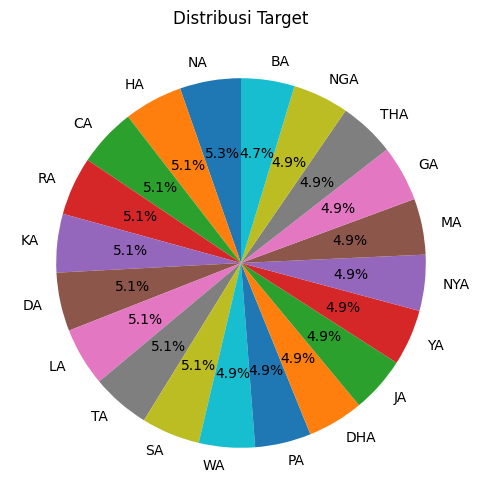

In [24]:
# Penyebaran target dengan grafik pie
plt.figure(figsize=(6,6))
df_train['HURUF'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Distribusi Target')
plt.show()


Dari grafik pie diatas, terlihat penyebaran data balance, dengan huruf terbanyak adalah huruf 'NA'.

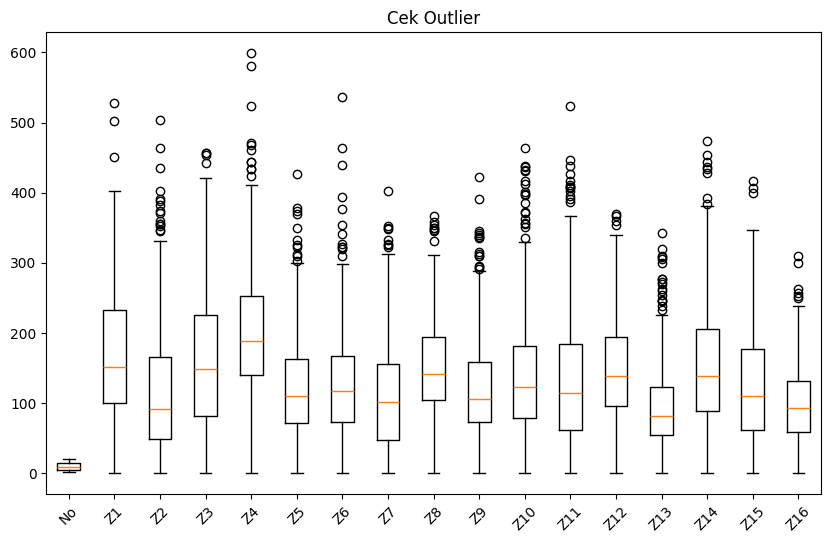

In [25]:
# Cek outlier pada setiap kolom
num_cols = df_train.select_dtypes(include='number')

plt.figure(figsize=(10,6))
plt.boxplot(num_cols)
plt.title('Cek Outlier')
plt.xticks(
    range(1, len(num_cols.columns)+1),
    num_cols.columns,
    rotation=45
)
plt.show()


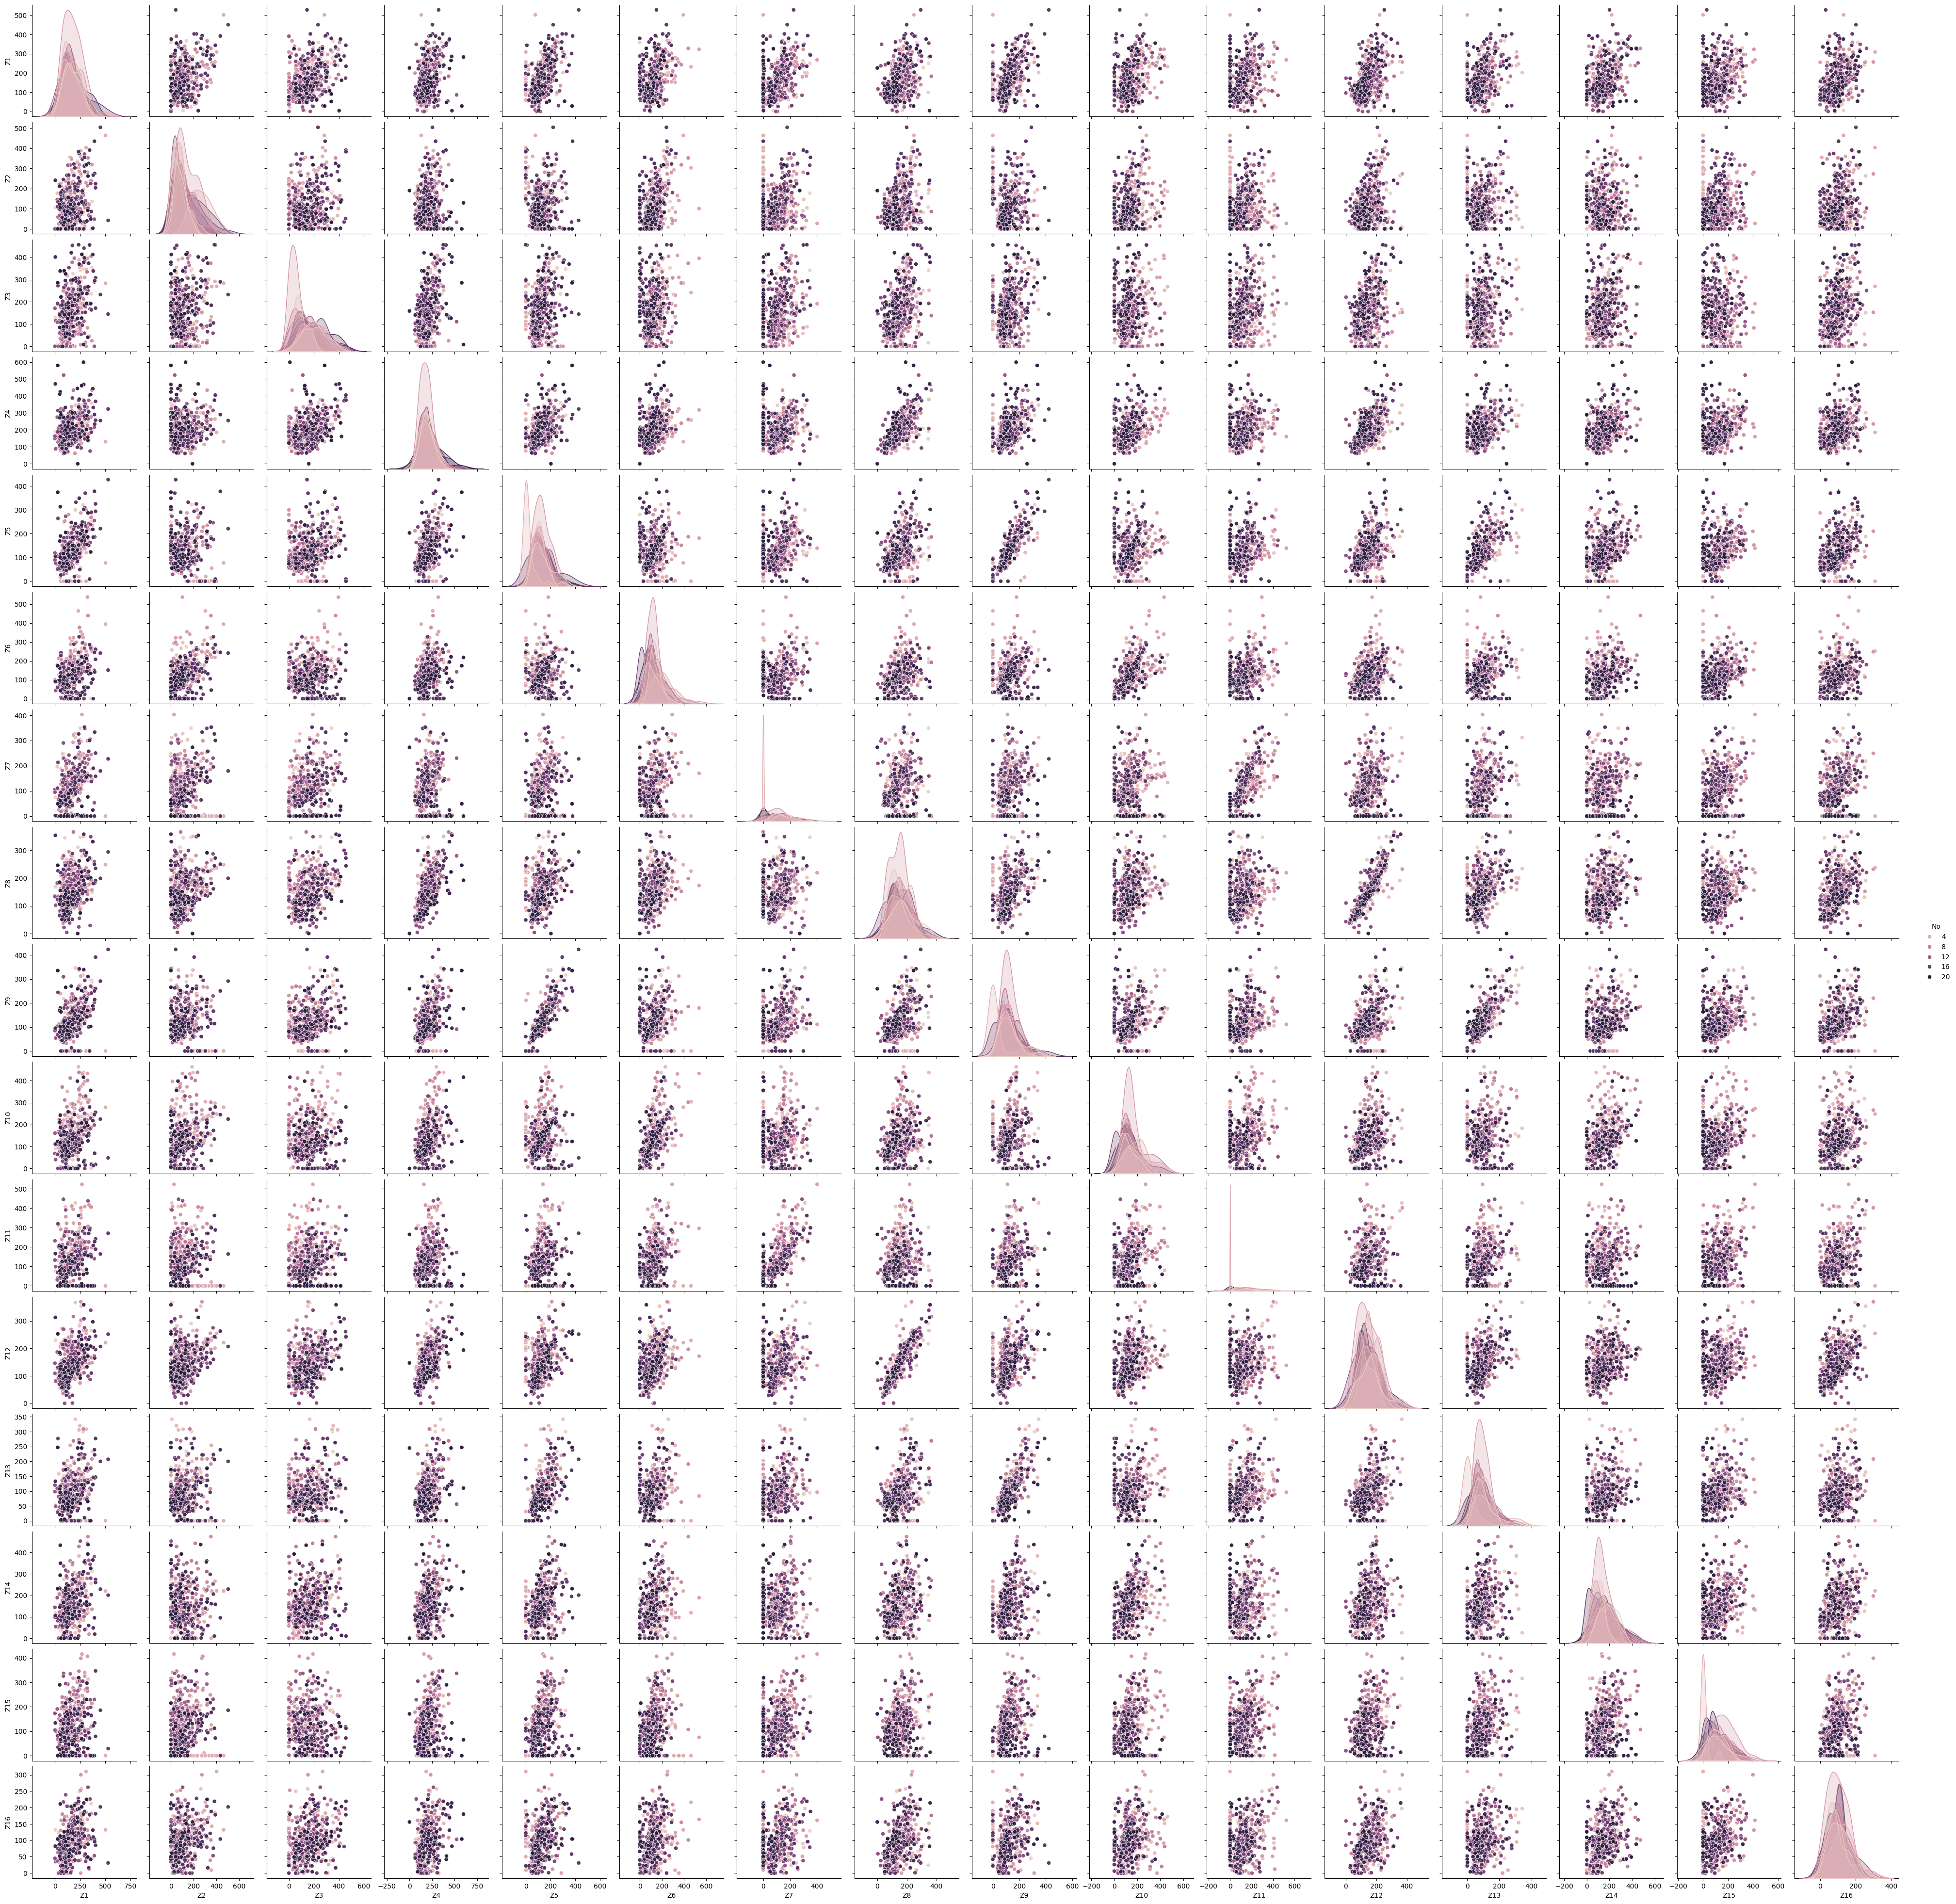

In [26]:
sns.pairplot(df_train, hue='No')
plt.show()

## 3. Model

In [27]:
# Variabel Independent dan Depemdent
X = num_cols.drop(columns=['No'])
y = num_cols['No']


In [28]:
np.random.seed(42)
indices = np.random.permutation(len(num_cols))
split = int(0.8 * len(num_cols))

train_idx = indices[:split]
val_idx   = indices[split:]

train_data = num_cols.iloc[train_idx]
val_data   = num_cols.iloc[val_idx]

X_train = train_data.drop(columns=['No']).values 
y_train = train_data['No'].values

X_val = val_data.drop(columns=['No']).values
y_val = val_data['No'].values

In [29]:
X_train = train_data.drop(columns=['No']).values
y_train = train_data['No'].values

X_val = val_data.drop(columns=['No']).values
y_val = val_data['No'].values

In [30]:
min_val = X_train.min(axis=0)
max_val = X_train.max(axis=0)

In [31]:
def minmax_norm(X, min_val, max_val):
    return (X - min_val) / (max_val - min_val + 1e-8)

In [32]:
X_train_norm = minmax_norm(X_train, min_val, max_val)
X_val_norm   = minmax_norm(X_val, min_val, max_val)


In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def knn_predict(X_train, y_train, x_test, k=3):
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], x_test)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]

    votes = {}
    for _, label in k_neighbors:
        votes[label] = votes.get(label, 0) + 1

    return max(votes, key=votes.get)



In [34]:
k_values = [3,5,7,9,11]

accuracies = []

for k in k_values:
    y_pred = []
    for x in X_val_norm:
        pred = knn_predict(X_train_norm, y_train, x, k=k)
        y_pred.append(pred)

    acc = np.mean(np.array(y_pred) == y_val)
    accuracies.append(acc)

    print(f"K = {k}, Akurasi = {acc:.4f}")


K = 3, Akurasi = 0.3889
K = 5, Akurasi = 0.3778
K = 7, Akurasi = 0.3778
K = 9, Akurasi = 0.3667
K = 11, Akurasi = 0.3889


In [35]:
best_k = k_values[np.argmax(accuracies)]
print("K terbaik:", best_k)


K terbaik: 3


In [48]:
knn_enc = knn_predict(X_train_norm, y_train, X_val_norm[0], k=best_k)
print(knn_enc)

8


In [37]:
y_pred = []

for x in X_val_norm:
    hasil = knn_predict(X_train_norm, y_train, x, k=3)
    y_pred.append(hasil)


In [38]:
y_pred = np.array(y_pred)
y_val  = np.array(y_val)

accuracy = np.mean(y_pred == y_val)
print("Akurasi Validasi:", accuracy)


Akurasi Validasi: 0.3888888888888889


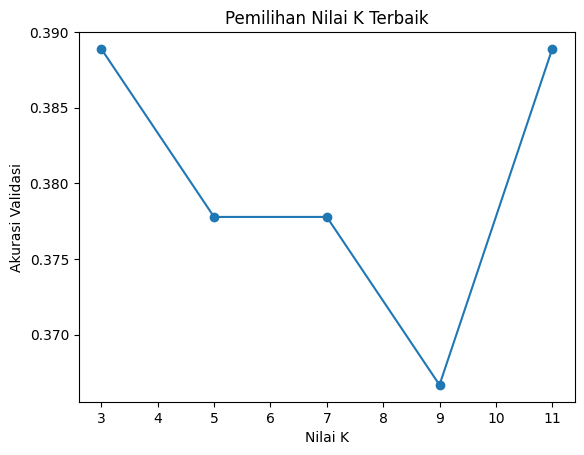

In [39]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi Validasi')
plt.title('Pemilihan Nilai K Terbaik')
plt.show()

## 4. Evaluasi

In [40]:
p = 2
def minkowski(a,b, p=2):
    return np.linalg.norm(a - b, ord=p)

def knn_min(X_train, y_train, x_test, k=3, p=2):
    distances = []
    for i in range(len(X_train)):
        dist = minkowski(X_train[i], x_test, p=p)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]

    votes = {}
    for _, label in k_neighbors:
        votes[label] = votes.get(label, 0) + 1

    return max(votes, key=votes.get)

knn_minkowski = knn_min(X_train_norm, y_train, X_val_norm[0], k=best_k, p=p)
print(knn_minkowski)

8


In [41]:
def manhattan(a,b):
    return np.sum(np.abs(a - b))

def knn_man(X_train, y_train, x_test, k=3):
    distances = []
    for i in range(len(X_train)):
        dist = manhattan(X_train[i], x_test)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]

    votes = {}
    for _, label in k_neighbors:
        votes[label] = votes.get(label, 0) + 1

    return max(votes, key=votes.get)

knn_manhattan = knn_man(X_train_norm, y_train, X_val_norm[0], k=best_k)
print(knn_minkowski)

8


In [49]:
def evaluate_multiclass_simple(y_true, y_pred):
    labels = np.unique(y_true)

    precisions = []
    recalls = []
    f1s = []

    for label in labels:
        TP = FP = FN = 0

        for yt, yp in zip(y_true, y_pred):
            if yt == label and yp == label:
                TP += 1
            elif yt != label and yp == label:
                FP += 1
            elif yt == label and yp != label:
                FN += 1

        precision = TP / (TP + FP) if (TP + FP) else 0
        recall    = TP / (TP + FN) if (TP + FN) else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    accuracy = np.mean(y_true == y_pred)

    return {
        "accuracy": accuracy,
        "precision_macro": np.mean(precisions),
        "recall": np.mean(recalls),
        "f1": np.mean(f1s)
    }

In [50]:
ev = evaluate_multiclass_simple(y_val, y_pred)
print(ev)

{'accuracy': np.float64(0.3888888888888889), 'precision_macro': np.float64(0.48383458646616545), 'recall': np.float64(0.38728070175438595), 'f1': np.float64(0.38359535201640466)}


## GUI

In [53]:
root = tk.Tk()
root.title("Prediksi Aksara")

inputs = []
for i in range(16):
    tk.Label(root, text=f"Z{i+1}").grid(row=i//4, column=(i%4)*2)
    ent = tk.Entry(root, width=5)
    ent.grid(row=i//4, column=(i%4)*2 + 1)
    inputs.append(ent)

def tebak():
    try:
        data_user = np.array([float(e.get()) for e in inputs])
        data_scaled = minmax_norm(data_user, min_val, max_val)        
        hasil = knn_predict(X_train_norm, y_train, data_scaled, k=best_k)        
        label_hasil.config(text=f"Aksara: {hasil}")

    except ValueError:
        messagebox.showerror("Error", "Input tidak valid. Harap masukkan 16 nilai numerik.")

btn = tk.Button(root, text="TEBAK", command=tebak, bg="yellow")
btn.grid(row=5, columnspan=8, pady=10)

label_hasil = tk.Label(root, text="Hasil: -", font=("Arial", 12, "bold"))
label_hasil.grid(row=6, columnspan=8)

root.mainloop()

In [45]:
192,200,68,280,148,188,343,253,166,187,156,313,148,76,16,146

(192, 200, 68, 280, 148, 188, 343, 253, 166, 187, 156, 313, 148, 76, 16, 146)

In [46]:
df_train.sample(5)

,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
70,4,RA,175,282,214,217,0,159,0,197,0,163,0,194,0,129,0,186
429,20,NGA,144,8,55,161,55,63,0,68,58,65,0,85,49,196,0,61
231,11,PA,112,31,75,90,60,62,55,69,53,59,51,67,49,100,99,40
401,18,BA,134,75,180,108,98,0,73,50,114,0,82,56,94,96,72,66
39,2,NA,243,53,55,232,126,121,192,131,127,318,297,282,154,126,203,250


In [47]:
df_test.sample(5)

,No. Urut,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
59,60,263,157,0,174,208,90,32,144,221,104,101,109,146,92,216,110
116,117,127,183,79,174,140,124,133,268,113,138,162,146,102,240,168,117
104,105,71,197,174,276,135,110,191,101,111,143,344,111,0,125,20,116
124,125,169,187,159,262,154,170,0,304,133,163,134,260,66,209,397,165
51,52,224,38,118,272,250,104,127,221,258,115,114,241,210,214,299,108
